In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import *
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
import warnings
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.pipeline import Pipeline
import torch.optim as optim
from xgboost import train
import CONSTANTS
from functions import *
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import clone
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from xgboostImplementation import XGBoost
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(fullDataPath(COIN))
data = data.loc[:, ~data.columns.str.contains('^Unnamed:')]
merged = dataSetup(data)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,close,gradient
time,,,,,,,,,,,,,
2015-07-20,268.225208,299.188792,52.0,0.000000,782.883420,-3.788651e+06,283.615714,4417.348637,277.37,280.00,277.98,280.00,0.00
2015-07-21,266.070954,300.106046,52.0,0.000000,4943.559434,-3.789434e+06,285.645714,5228.512882,276.85,281.27,279.96,277.32,-2.68
2015-07-22,263.804410,301.155590,52.0,0.000000,4687.909383,-3.784491e+06,288.280000,5345.414337,275.01,278.54,277.33,277.89,0.57
2015-07-23,263.024045,301.345955,52.0,0.000000,5306.919575,-3.789178e+06,290.037143,5421.928306,276.28,279.75,277.96,277.39,-0.50
2015-07-24,261.412051,301.912949,52.0,0.000000,7362.469083,-3.783871e+06,291.622857,5397.937160,276.43,291.52,277.23,289.12,11.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-06,102002.750492,113100.626508,50.0,0.153323,1651.181202,-1.427313e+04,109661.780000,0.000000,107837.70,109736.64,108246.66,109217.98,971.33
2025-07-07,102002.750492,113100.626508,52.0,-0.000980,4455.083530,-1.592431e+04,109661.780000,0.000000,107507.00,109741.64,109217.98,108269.84,-948.14
2025-07-08,102002.750492,113100.626508,50.0,0.207989,3785.390742,-1.146922e+04,109661.780000,0.000000,107438.33,109255.99,108271.49,108958.04,688.20


# XGBoost Implementation

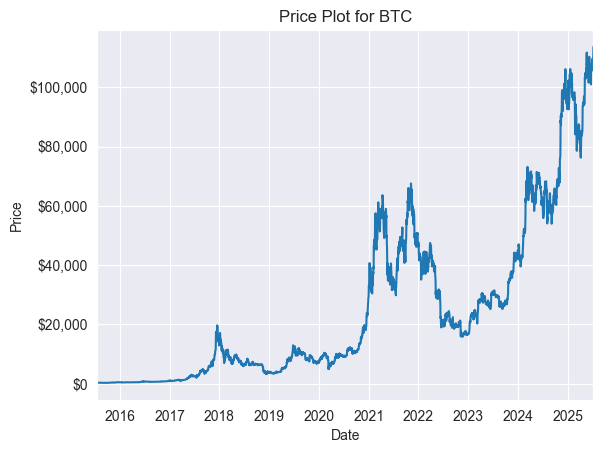

In [3]:
merged['close'].plot.line()
plt.title(f'Price Plot for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
# format y axis to show currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))

In [4]:
scaler = StandardScaler()
closeScaler = StandardScaler()
mergedIndex = merged.index
mergedCols = merged.columns

mergedWithoutClose = merged.drop(columns=['close'])
mwocCols = mergedWithoutClose.columns
mwocIndex = mergedWithoutClose.index
mergedWithoutClose = scaler.fit_transform(mergedWithoutClose)
mergedWithoutClose = pd.DataFrame(mergedWithoutClose, index=mergedIndex, columns=mwocCols)

merged['close'] = closeScaler.fit_transform(merged['close'].values.reshape(-1, 1))
merged = pd.concat([mergedWithoutClose, merged['close']], axis=1)
merged

,BB_Lower,BB_Upper,value,avg_sentiment,volume,OBV,SMA_7,Volume_MA_7,low,high,open,gradient,close
time,,,,,,,,,,,,,
2015-07-20,-0.884434,-0.926185,-0.060930,-0.014144,-1.146748,-1.990097,-0.907116,-1.125353,-0.902675,-0.909428,-0.906515,-0.028575,-0.906392
2015-07-21,-0.884518,-0.926154,-0.060930,-0.014144,-0.790120,-1.990772,-0.907042,-1.031602,-0.902694,-0.909383,-0.906443,-0.031037,-0.906489
2015-07-22,-0.884606,-0.926119,-0.060930,-0.014144,-0.812033,-1.986513,-0.906947,-1.018091,-0.902762,-0.909480,-0.906539,-0.028051,-0.906468
2015-07-23,-0.884637,-0.926113,-0.060930,-0.014144,-0.758975,-1.990551,-0.906883,-1.009248,-0.902715,-0.909437,-0.906516,-0.029034,-0.906487
2015-07-24,-0.884700,-0.926094,-0.060930,-0.014144,-0.582786,-1.985979,-0.906826,-1.012021,-0.902710,-0.909017,-0.906543,-0.017799,-0.906061
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-06,3.088653,2.828479,-0.371026,0.083454,-1.072323,1.261568,3.053913,-1.635890,3.090309,2.993022,3.019279,0.863722,3.049488
2025-07-07,3.088653,2.828479,-0.060930,-0.014768,-0.831989,1.260145,3.053913,-1.635890,3.078032,2.993201,3.054596,-0.899568,3.015058
2025-07-08,3.088653,2.828479,-0.371026,0.118252,-0.889391,1.263984,3.053913,-1.635890,3.075483,2.975886,3.020181,0.603629,3.040049


In [5]:
training_cols = trainingCols()
X = merged[training_cols]
y = merged['close']
n = len(data)

merged = transformerDataSetup(merged)
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(merged, testSize=len(merged)-TEST_DAYS)
train_stuff = merged.loc[X_train.index, training_cols]
test_stuff = merged.loc[X_test.index, training_cols]
X_train_norm = pd.concat([X_train, train_stuff], axis=1)
X_test_norm = pd.concat([X_test, test_stuff], axis=1)

X_train_norm.shape, X_test_norm.shape, y_train.shape, y_test.shape

((3637, 12), (7, 12), (3637,), (7,))

In [6]:
xgb_model = XGBoost(
    base_estimator=RandomForestRegressor(n_estimators=50),
    n_estimators=50,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
)

In [ ]:
xgb_model.fit(X_train_norm, y_train)
predictions = xgb_model.predict(X_test_norm.iloc[[-1]]) # Predicting for the future 7 days
xgb_model.save(f'models/{COIN}_full_xgb_model_everything.pkl')

predictions = np.array(predictions)
predictions = predictions.reshape(-1, 1)
predictions = closeScaler.inverse_transform(predictions)
predictions = pd.DataFrame(predictions, columns=['predictions'])
predictions.index = pd.date_range(start=merged.index.max(), periods=TEST_DAYS, freq='D')
if not os.path.exists(f'predictions/{COIN}'):
    os.makedirs(f'predictions/{COIN}')
predictions.to_csv(f'predictions/{COIN}/xgb_predictions.csv')
predictions.plot.line()
plt.title(f'Predictions from XGB for {COIN}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}".format(int(x))))
plt.show()

In [15]:
predictions_1 = xgb_model.predict(X_test_norm.iloc[[-2]])
predictions_1 = np.array(predictions_1)
predictions_1 = predictions_1.reshape(-1, 1)
predictions_1 = closeScaler.inverse_transform(predictions_1)
predictions_1 = pd.DataFrame(predictions_1, columns=['predictions'])
predictions_1['actual'] = closeScaler.inverse_transform(np.array(y_test.iloc[-2]).reshape(-1, 1))

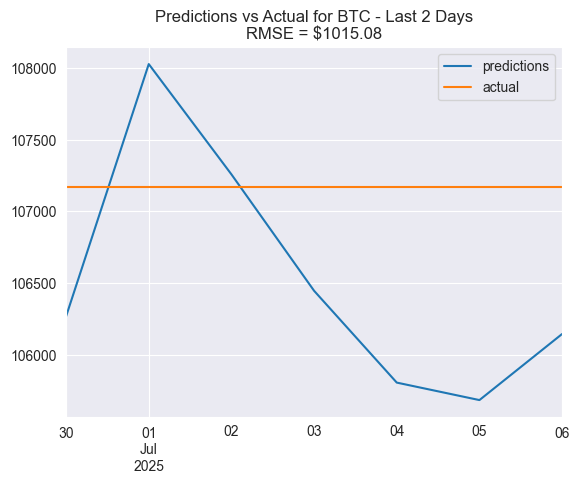

In [29]:
predictions_1.index = pd.date_range(merged.index.max()-pd.Timedelta(days=1), periods=len(predictions_1), freq='D')
predictions_1.plot.line()
mse = mean_squared_error(predictions_1['actual'], predictions_1['predictions'], squared=False)
plt.title(f'Predictions vs Actual for {COIN} - Last 2 Days\nRMSE = ${mse:.2f}')
plt.show()